In [26]:
import tensorflow as tf

In [27]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('dark_background')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder 
from tensorflow.keras.utils import to_categorical
import os

In [28]:
encoder=OneHotEncoder()
encoder.fit([[0],[1]])
#0-tomoto
#1-apple

OneHotEncoder()

In [29]:
data=[]
paths=[]
result=[]

Apple


In [30]:
for r,d,f in os.walk(r"E:\Shadil\CNN\Apple tomato dectection\apples"):
    for file in f:
        if'.jpeg' or '.jpg' in file:
            paths.append(os.path.join(r,file))

for path in paths:
    img=Image.open(path)
    img=img.resize((128,128))
    img=np.array(img)
    if(img.shape==(128,128,3)):
        data.append(np.array(img))
        result.append(encoder.transform([[1]]).toarray())

Tomato

In [31]:
paths=[]
for r,d,f in os.walk(r"E:\Shadil\CNN\Apple tomato dectection\tomatoes"):
    for file in f:
        if'.jpg' or '.jpeg' in file:
            paths.append(os.path.join(r,file))

for path in paths:
    img=Image.open(path)
    img=img.resize((128,128))
    img=np.array(img)
    if(img.shape==(128,128,3)):
        data.append(np.array(img))
        result.append(encoder.transform([[0]]).toarray())

In [32]:
type(data)

list

In [33]:
type(result)

list

In [34]:
data=np.array(data)
data.shape

(290, 128, 128, 3)

In [35]:
result=np.array(result)
result=result.reshape(290,2)

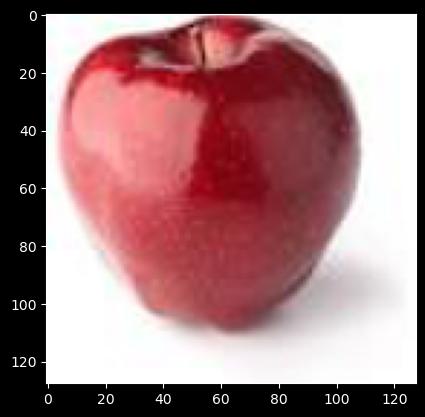

In [36]:
plt.imshow(data[0])

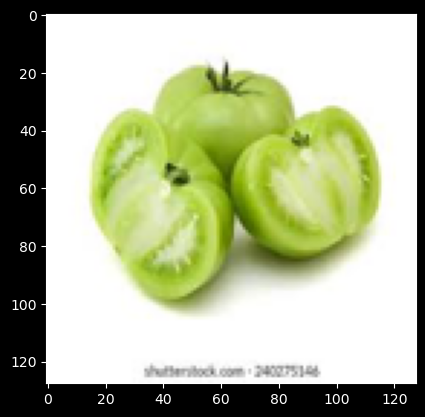

In [37]:
plt.imshow(data[230])

In [38]:
x_train,x_test,y_train,y_test=train_test_split(data,result,test_size=0.2,shuffle=True,random_state=0)

In [39]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3, 3), input_shape=(128, 128, 3), padding = 'Same'))
model.add(Conv2D(32, kernel_size=(3, 3),  activation ='relu', padding = 'Same'))
model.add(Dropout(0.45))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, kernel_size = (3,3), activation ='relu', padding = 'Same'))
model.add(Conv2D(64, kernel_size = (3,3), activation ='relu', padding = 'Same'))
model.add(Dropout(0.45))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='sigmoid'))

print(model.summary())

c:\Users\GCE PMNA\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    33,554,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,621,922 (128.26 MB)

 Trainable params: 33,621,730 (128.26 MB)

 Non-trainable params: 192 (768.00 B)

None


In [40]:
model.compile(loss="binary_crossentropy",optimizer='sgd',metrics=['accuracy'])

In [41]:
x_train.shape

(232, 128, 128, 3)

In [42]:
x_train.shape

(232, 128, 128, 3)

In [43]:
history=model.fit(x_train,y_train,epochs=20,batch_size=64,verbose=1,validation_data=(x_test,y_test))

Epoch 1/20


4/4 ━━━━━━━━━━━━━━━━━━━━ 25s 5s/step - accuracy: 0.5086 - loss: 4.7999 - val_accuracy: 0.5000 - val_loss: 2.9934
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.6466 - loss: 0.8598 - val_accuracy: 0.5172 - val_loss: 0.9757
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.7155 - loss: 0.6603 - val_accuracy: 0.5345 - val_loss: 1.0216
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.7241 - loss: 0.5954 - val_accuracy: 0.5000 - val_loss: 0.9490
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.7759 - loss: 0.4817 - val_accuracy: 0.5345 - val_loss: 0.8320
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.7845 - loss: 0.4538 - val_accuracy: 0.5000 - val_loss: 1.0780
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.8017 - loss: 0.4609 - val_accuracy: 0.5862 - val_loss: 0.6874
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 23s 6s/step - accuracy: 0.7845 - loss: 0.4925 - val_accuracy: 0.5690 - val_loss: 0.7114
Epoch 9/20
4/4 ━━━━

In [44]:
score=model.evaluate(x_test,y_test,batch_size=64)
print(f"\nTest accuracy: {100.0 * score[1]:.1f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5345 - loss: 0.7175   

Test accuracy: 53.4%


In [45]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(
    r"E:\Shadil\CNN\red-apple-cut-half-water-260nw-2532255795.webp",
    target_size=(128, 128) 
)

# Convert to array and normalize
img_array =np.array(img)

# Reshape to (1, 128, 128, 3) for model prediction
img_array = img_array.reshape(1, 128, 128, 3)

print(img_array.shape)  # should be (1, 128, 128, 3)

FileNotFoundError: [Errno 2] No such file or directory: 'E:\\Shadil\\CNN\\red-apple-cut-half-water-260nw-2532255795.webp'

In [ ]:
class_names = ['Tomato','Apple']

prediction = model.predict(img_array)
predicted_index = np.argmax(prediction)
predicted_label = class_names[predicted_index]

print("Predicted class:", predicted_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step
Predicted class: Apple
